
## Limpieza de datos para pobreza_laboral_jefatura_sexo.csv obtenido de: Cuadro_de_indicadores_ITLP_4T2024.xlsx

El archivo `pobreza_laboral_jefatura_sexo.csv` considera el siguiente indicador: **Porcentaje de la poblacion (hogares) en pobreza laboral**, que en comparacion el archivo `pobreza_poblacion_ocupada_sexo.csv`, este contempla la pobreza por hogar, y no a nivel individual. Registra el porcentaje de la poblacion (hogares) en pobreza a nivel nacional, y el porcentaje de estos que estan liderados por hombres o por mujeres. De igual manera, registra el ingreso de los hogares. Esto es importante para observar la brecha economica que existe entre los hogares liderados.

In [25]:
import pandas as pd
import numpy as np

# declaramos la ruta
ruta = '../data/pobreza_laboral_jefaura_sexo.csv'

#Leemos el dataset "sucio" para inspeccionar
df_raw = pd.read_csv(ruta, header=None)
#df_raw.info()

In [26]:
#Cargar el CSV con solo los datos que nos interesan
df_pobreza_hogares = pd.read_csv(ruta, header=None, skiprows=6)

In [27]:
# Nos saltamos la columna sin valores
df_pobreza_hogares = df_pobreza_hogares.iloc[:, [0, 1, 2, 3, 4, 6, 7, 8]]

In [28]:
# Definimos los nombres de las columnas claros y distintivos
df_pobreza_hogares.columns = [
    'anio', 'trimestre', 
    'pob_jefatura_nal', 'pob_jefatura_hombres', 'pob_jefatura_mujeres',
    'ing_jefatura_nal', 'ing_jefatura_hombres', 'ing_jefatura_mujeres'
]

In [29]:
# Rellenar los años (ffill) y limpiar filas de basura/notas al pie
df_pobreza_hogares['anio'] = df_pobreza_hogares['anio'].ffill()
df_pobreza_hogares = df_pobreza_hogares[df_pobreza_hogares['anio'].astype(str).str.contains(r'20\d{2}', na=False)].copy()

In [30]:
# Función robusta para limpiar números (quita $, comas, asteriscos y "ND")
def clean_itlp_numbers(val):
    if pd.isna(val): return np.nan
    s = str(val).strip().replace('$', '').replace(',', '').replace('*', '')
    if s in ['-', 'ND', 'N.D.', '']: return np.nan
    try: return float(s)
    except: return np.nan

cols_num = ['pob_jefatura_nal', 'pob_jefatura_hombres', 'pob_jefatura_mujeres',
            'ing_jefatura_nal', 'ing_jefatura_hombres', 'ing_jefatura_mujeres']

for col in cols_num:
    df_pobreza_hogares[col] = df_pobreza_hogares[col].apply(clean_itlp_numbers)

In [31]:
# Estandarizar trimestres
def fix_trim(t):
    t = str(t).upper().replace('*', '').strip()
    return 'II' if t == 'LL' else t # Corrección para el error de dedo en 2020

df_pobreza_hogares['trimestre_std'] = df_pobreza_hogares['trimestre'].apply(fix_trim)
mapping_trim = {'I': '01-01', 'II': '04-01', 'III': '07-01', 'IV': '10-01'}

In [32]:
# Crear columna de fecha real
df_pobreza_hogares['fecha'] = pd.to_datetime(df_pobreza_hogares['anio'].astype(int).astype(str) + '-' + df_pobreza_hogares['trimestre_std'].map(mapping_trim))

# Dataset Final Ordenado
df_jefatura_limpio = df_pobreza_hogares[['fecha', 'anio', 'trimestre'] + cols_num].sort_values('fecha').reset_index(drop=True)

In [33]:
# Mostramos las primeras 10 filas de nuestro df
df_jefatura_limpio.head(10)

,fecha,anio,trimestre,pob_jefatura_nal,pob_jefatura_hombres,pob_jefatura_mujeres,ing_jefatura_nal,ing_jefatura_hombres,ing_jefatura_mujeres
0,2005-01-01,2005.0,I,38.1,36.2,45.2,2605.92,2700.40,2268.47
1,2005-04-01,2005.0,II,38.8,36.4,46.7,2608.59,2710.83,2285.59
2,2005-07-01,2005.0,III,38.1,35.5,46.8,2641.13,2747.83,2271.76
3,2005-10-01,2005.0,IV,36.6,34.4,43.8,2729.02,2838.33,2357.85
4,2006-01-01,2006.0,I,36.2,34.0,43.7,2722.13,2821.10,2386.72
5,2006-04-01,2006.0,II,35.2,32.8,42.8,2783.78,2894.60,2423.35
6,2006-07-01,2006.0,III,35.8,33.5,43.2,2828.56,2945.92,2432.37
7,2006-10-01,2006.0,IV,36.3,34.2,43.3,2772.54,2886.37,2388.75
8,2007-01-01,2007.0,I,36.5,34.3,43.3,2768.23,2874.17,2416.61
9,2007-04-01,2007.0,II,34.7,32.4,41.7,2833.26,2944.79,2479.18


In [34]:
#última verificación de los tipos de datos
print(df_jefatura_limpio.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha                 80 non-null     datetime64[ns]
 1   anio                  80 non-null     float64       
 2   trimestre             80 non-null     object        
 3   pob_jefatura_nal      79 non-null     float64       
 4   pob_jefatura_hombres  79 non-null     float64       
 5   pob_jefatura_mujeres  79 non-null     float64       
 6   ing_jefatura_nal      79 non-null     float64       
 7   ing_jefatura_hombres  79 non-null     float64       
 8   ing_jefatura_mujeres  79 non-null     float64       
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 5.8+ KB
None


In [35]:
df_jefatura_limpio.to_csv('../data/clean_data/pobreza_laboral_jefatura_sexo_clean.csv', index=False)

## Visualizacion

In [38]:
# Importamos las librerias para visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

La graficacion de los datos de este dataset nos permitiran observar y comparar directamente el riesgo de pobreza entre un hogar liderado por un hombre vs. uno liderado por una mujer.

c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

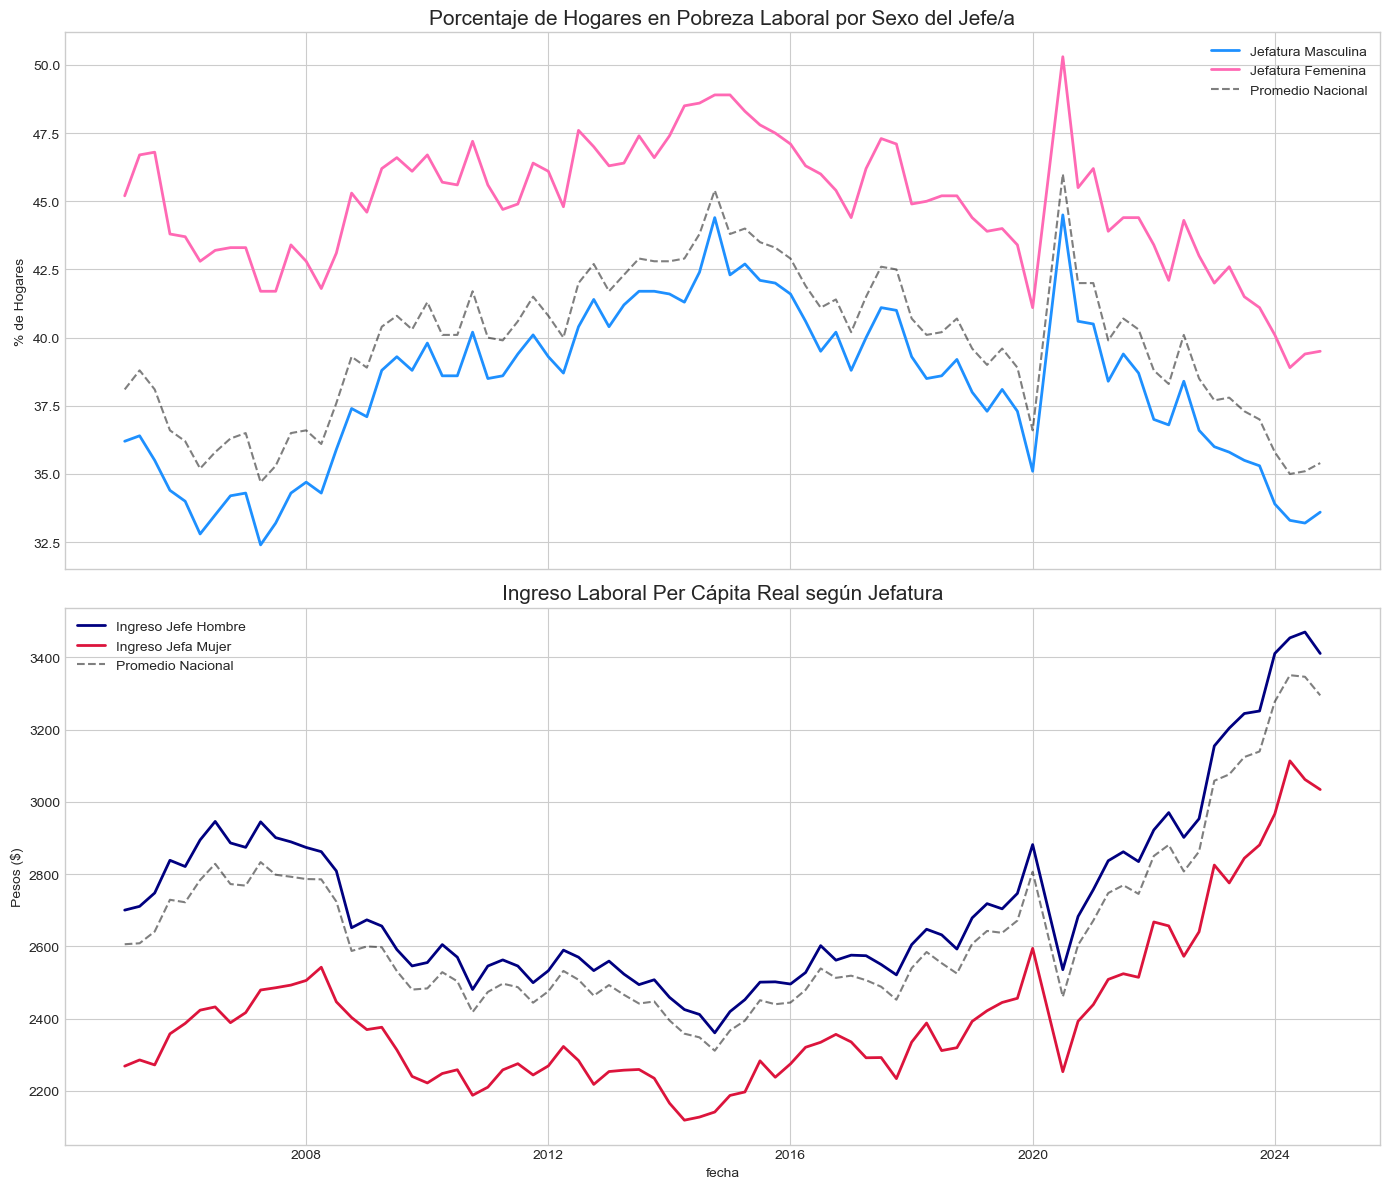

In [40]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# --- Pobreza en el Hogar ---
sns.lineplot(data=df_jefatura_limpio, x='fecha', y='pob_jefatura_hombres', ax=ax1, 
             color='dodgerblue', label='Jefatura Masculina', linewidth=2)
sns.lineplot(data=df_jefatura_limpio, x='fecha', y='pob_jefatura_mujeres', ax=ax1, 
             color='hotpink', label='Jefatura Femenina', linewidth=2)
# Referencia Nacional
sns.lineplot(data=df_jefatura_limpio, x='fecha', y='pob_jefatura_nal', ax=ax1, 
             color='black', linestyle='--', alpha=0.5, label='Promedio Nacional')

ax1.set_title('Porcentaje de Hogares en Pobreza Laboral por Sexo del Jefe/a', fontsize=15)
ax1.set_ylabel('% de Hogares')

# --- Ingreso del Hogar ---
sns.lineplot(data=df_jefatura_limpio, x='fecha', y='ing_jefatura_hombres', ax=ax2, 
             color='navy', label='Ingreso Jefe Hombre', linewidth=2)
sns.lineplot(data=df_jefatura_limpio, x='fecha', y='ing_jefatura_mujeres', ax=ax2, 
             color='crimson', label='Ingreso Jefa Mujer', linewidth=2)
# Referencia Nacional
sns.lineplot(data=df_jefatura_limpio, x='fecha', y='ing_jefatura_nal', ax=ax2, 
             color='black', linestyle='--', alpha=0.5, label='Promedio Nacional')

ax2.set_title('Ingreso Laboral Per Cápita Real según Jefatura', fontsize=15)
ax2.set_ylabel('Pesos ($)')

plt.tight_layout()
plt.show()

### La brecha de Jefatura
Calcularemos la brecha que hay en los hogares liderados por mujeres y aquellos liderados por hombres con la formula matematica: 
$$\text{Radio de ingresos}= \dfrac{\text{ingresos hogares liderados por mujeres}}{\text{ingresos hogares liderados por hombres}}$$
Esta es una métrica de equidad estructural. Nos dice qué tan castigado está económicamente un hogar solo por tener a una mujer al frente.

c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


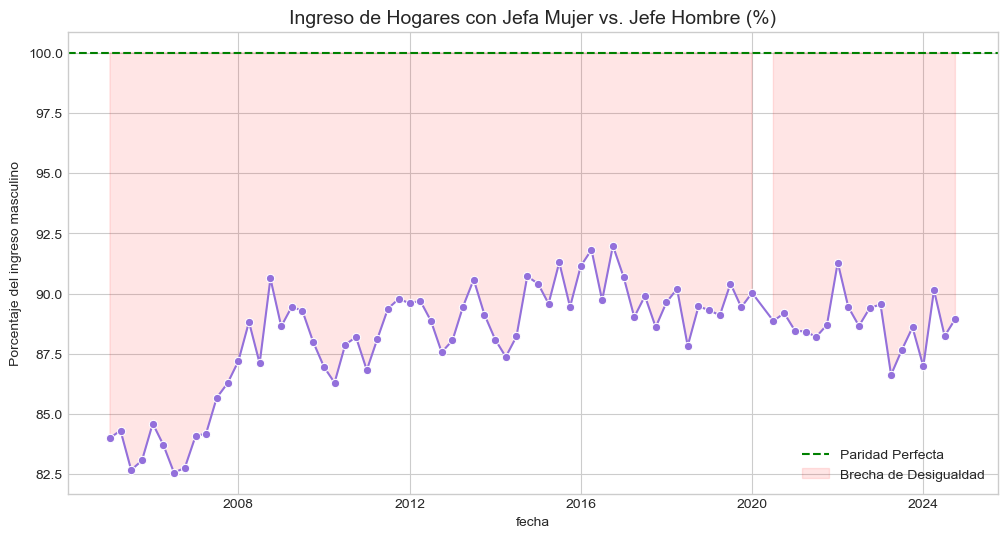

In [42]:
# Calculamos la proporción: ¿Qué % del ingreso de un hombre gana una mujer jefa de hogar?
df_jefatura_limpio['ratio_ingreso_jefatura'] = (df_jefatura_limpio['ing_jefatura_mujeres'] / df_jefatura_limpio['ing_jefatura_hombres']) * 100

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_jefatura_limpio, x='fecha', y='ratio_ingreso_jefatura', color='mediumpurple', marker='o')

# Línea de paridad
plt.axhline(100, color='green', linestyle='--', label='Paridad Perfecta')
plt.fill_between(df_jefatura_limpio['fecha'], df_jefatura_limpio['ratio_ingreso_jefatura'], 100, color='red', alpha=0.1, label='Brecha de Desigualdad')

plt.title('Ingreso de Hogares con Jefa Mujer vs. Jefe Hombre (%)', fontsize=14)
plt.ylabel('Porcentaje del ingreso masculino')
plt.legend()
plt.show()

### Correlacion: ¿Pobreza e Ingreso van de la mano?
Con la siguiente matriz de correlaicon podremos verificar si la caída en el ingreso del jefe afecta de igual manera a la pobreza en ambos géneros.

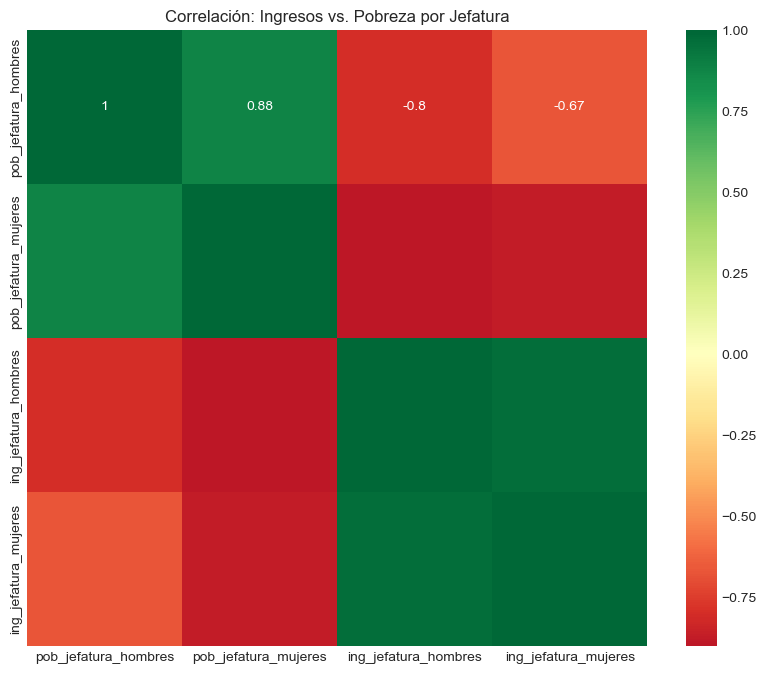

In [43]:
plt.figure(figsize=(10, 8))
# Seleccionamos solo las variables numéricas de interés
cols_corr = ['pob_jefatura_hombres', 'pob_jefatura_mujeres', 'ing_jefatura_hombres', 'ing_jefatura_mujeres']
correlation = df_jefatura_limpio[cols_corr].corr()

sns.heatmap(correlation, annot=True, cmap='RdYlGn', center=0)
plt.title('Correlación: Ingresos vs. Pobreza por Jefatura')
plt.show()